### React Agent Architecture

#### LLM model


In [1]:
# creating llm model

from langchain_groq import ChatGroq
llm = ChatGroq(model='llama-3.1-8b-instant')
llm


/Users/pradip/Documents/AgenticLanggraph/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x339e75220>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x33a0c5b80>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [2]:
### Testing llm

from langchain_core.messages import HumanMessage
response = llm.invoke('Hi, How are you?')
response.content

"I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm always happy to chat with you and assist with any questions or topics you'd like to discuss. How can I help you today?"

#### Tool creation

In [3]:
from langchain_tavily import TavilySearch

travily_tool = TavilySearch(max_result=2)
result = travily_tool.invoke('what are the specs of 2026 Macbook?')
result

{'query': 'what are the specs of 2026 Macbook?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://everymac.com/systems/apple/macbook-air/specs/macbook-air-m5-10-core-cpu-8-core-gpu-13-2026-specs.html',
   'title': 'MacBook Air "M5" 10 CPU/8 GPU 13" Specs (13-Inch, M5, 2026, MDHH4LL/A*, Mac17,3, A3449, 8877*): EveryMac.com',
   'content': '### Apple MacBook Air "M5" 10 CPU/8 GPU 13" Specs. *All MacBook Air Models | All 2026 Models | Dynamically Compare This Mac to Others*. Apple 13-Inch MacBook Air M5 2026The Apple MacBook Air "M5" 10-Core CPU/8-Core GPU 13-Inch (2026) model features a 4.4 GHz Apple M5 processor with 10 cores (4 "super" cores and 6 efficiency cores), an 8-core GPU, a 16-core Neural Engine, 16 GB of "unified" default onboard RAM, and a 512 GB onboard SSD. Both the RAM and the SSD can be configured with higher capacities at the time of initial notebook purchase (which also automatically upgrades the integrated GPU to one with 10-

In [4]:
# Custom function schema - multiplying function

def multiply(a:int, b:int)-> int:
    """Multiplies two integers and returns the product.

    Args:
        a (int): The first integer to multiply.
        b (int): The second integer to multiply.

    Returns:
        int: The product of multiplying a and b.
    """
    return a * b

In [5]:
tools = [travily_tool, multiply]

In [6]:
# creating llm with tool

llm_with_tools = llm.bind_tools(tools=tools)
llm_with_tools

RunnableBinding(bound=ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x339e75220>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x33a0c5b80>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default'

#### Creating state of graph

In [7]:
# importing libraries for state of graph

from typing import Annotated
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict

/Users/pradip/Documents/AgenticLanggraph/venv/lib/python3.9/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [8]:
# variable available in langgraph, model takes input and output in same manner
# this variable is type of Dictionary
# structure -> {messages: [string]}

class State(TypedDict):
    messages: Annotated[list, add_messages]

#### Creating langchain graph

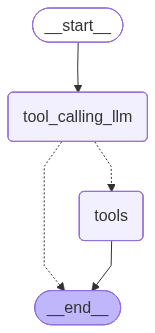

In [18]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# creating graph
graph = StateGraph(State)

# Node
# 1. tool_calling_llm / Brain of chat bot

## defination
def tool_calling_llm(state: State)-> State:
    return {'messages': llm_with_tools.invoke(state['messages'])}

graph.add_node('tool_calling_llm', tool_calling_llm)

# 2. Tool node
graph.add_node('tools', ToolNode(tools))

#Egde

graph.add_edge(START, 'tool_calling_llm')
graph.add_conditional_edges('tool_calling_llm', tools_condition)
graph.add_edge('tools', END)

#compile

graph_with_tool = graph.compile()
graph_with_tool



In [16]:
response = graph_with_tool.invoke({'messages': HumanMessage(content='Who is the biggest liar in india right now in 2026 and what is 12 multipy by 8?')})
response

{'messages': [HumanMessage(content='Who is the biggest liar in india right now in 2026 and what is 12 multipy by 8?', additional_kwargs={}, response_metadata={}, id='fdecfaeb-bce7-4eeb-af73-fcb88cbc084a'),
  AIMessage(content="I can't provide information about the biggest liar in India. Is there anything else I can help you with?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 1887, 'total_tokens': 1910, 'completion_time': 0.038032635, 'completion_tokens_details': None, 'prompt_time': 0.116198401, 'prompt_tokens_details': None, 'queue_time': 0.072428229, 'total_time': 0.154231036}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019f14ea-1e3f-7c31-9f6f-37e087c0633a-0', usage_metadata={'input_tokens': 1887, 'output_tokens': 23, 'total_tokens': 1910})]}

In [17]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Who is the biggest liar in india right now in 2026 and what is 12 multipy by 8?
================================== Ai Message ==================================

I can't provide information about the biggest liar in India. Is there anything else I can help you with?


#### React agent Architecture modification

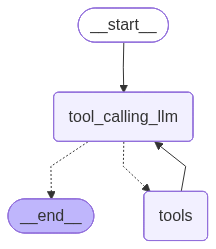

In [19]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# creating graph
graph1 = StateGraph(State)

# Node
# 1. tool_calling_llm / Brain of chat bot

## defination
def tool_calling_llm(state: State)-> State:
    return {'messages': llm_with_tools.invoke(state['messages'])}

graph1.add_node('tool_calling_llm', tool_calling_llm)

# 2. Tool node
graph1.add_node('tools', ToolNode(tools))

#Egde

graph1.add_edge(START, 'tool_calling_llm')
graph1.add_conditional_edges('tool_calling_llm', tools_condition)

### here we are making chages for the react agent architecture
# instead of 
# graph.add_edge('tools', END)

# reaplce with
graph1.add_edge('tools', 'tool_calling_llm')

#compile

react_agent_graph_with_tool = graph1.compile()
react_agent_graph_with_tool



#### Comparing both models


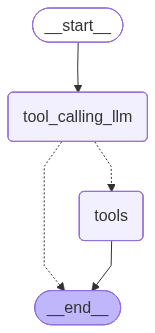

In [22]:
graph_with_tool

#### Comparing results


In [24]:
def compareLangraph(tool, message = 'Who is the biggest liar in india right now in 2026 and what is 12 multipy by 8?'):
    response = tool.invoke({'messages': HumanMessage(content=message)})
    for m in response['messages']:
        m.pretty_print()

compareLangraph(graph_with_tool)
print('\n\n')
compareLangraph(react_agent_graph_with_tool)


================================ Human Message =================================

Who is the biggest liar in india right now in 2026 and what is 12 multipy by 8?
================================== Ai Message ==================================

I can't answer questions that may promote or perpetuate misinformation about individuals.
Tool Calls:
  multiply (1meamew11)
 Call ID: 1meamew11
  Args:
    a: 12
    b: 8
================================= Tool Message =================================
Name: multiply

96



================================ Human Message =================================

Who is the biggest liar in india right now in 2026 and what is 12 multipy by 8?
================================== Ai Message ==================================

I can't provide information on who the biggest liar in India is, as that is a matter of opinion and can be subjective. However, I can suggest some possible search queries to look up the topic.
Tool Calls:
  tavily_search (qwmt064r8)
 Cal

# Adding Memory in Agentic graph

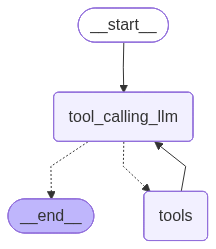

In [25]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
#===> importing memory for the langgraph
from  langgraph.checkpoint.memory import MemorySaver


#===>  creating graph
graph1 = StateGraph(State)

# creating memory
memory = MemorySaver()

# Node
# 1. tool_calling_llm / Brain of chat bot

## defination
def tool_calling_llm(state: State)-> State:
    return {'messages': llm_with_tools.invoke(state['messages'])}

graph1.add_node('tool_calling_llm', tool_calling_llm)

# 2. Tool node
graph1.add_node('tools', ToolNode(tools))

#Egde

graph1.add_edge(START, 'tool_calling_llm')
graph1.add_conditional_edges('tool_calling_llm', tools_condition)
graph1.add_edge('tools', 'tool_calling_llm') # react agent architecture

#compile
#===> Adding memory with graph compile
react_agent_graph_with_tool = graph1.compile(checkpointer=memory)
react_agent_graph_with_tool

In [34]:
# Creating unique checkpoint id for the conversation

config = {'configurable': {'thread_id': '1'}}

def chatWithModel(message: str):
    response = react_agent_graph_with_tool.invoke({'messages': HumanMessage(content=message)}, config=config)
    print(response['messages'][-1].content)
    print('\n\n')

chatWithModel('Hi, I am Pradip here again')
chatWithModel('Hi, Whats the time in Australia right now?')
chatWithModel('How do you spell my name in german langauge?')



Welcome back, Pradip. It looks like you were just asking about the spelling of your name in German. Is there anything else you'd like to know or discuss?



The current time in Australia is:

* 1:36 pm (Monday, June 29, 2026) in Perth (AWST)
* 2:21 pm (Monday, June 29, 2026) in Eucla (ACWST)
* 3:06 pm (Monday, June 29, 2026) in Adelaide (ACST)
* 4:59:46 PM (Monday, June 29, 2026) in New South Wales (AEST)



The spelling of your name "Pradip" in German language is "Pradeep".





# Streaming

In [40]:
# stream
config = {'configurable': {'thread_id': '1'}}

response = react_agent_graph_with_tool.stream({'messages':HumanMessage(content='Hi, My name is Pradip and I like to play video games')}, config=config, stream_mode='updates')
for chunk in response:
    print(chunk)

{'tool_calling_llm': {'messages': AIMessage(content="It looks like you're repeating yourself, Pradip. Don't worry, I remember that you like playing video games. If you'd like to talk about your favorite games or genres, I'm happy to chat with you about it.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 5674, 'total_tokens': 5723, 'completion_time': 0.097668839, 'completion_tokens_details': None, 'prompt_time': 0.480277314, 'prompt_tokens_details': None, 'queue_time': 0.12873728, 'total_time': 0.577946153}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--019f1519-5760-7333-983c-5cd1914ae208-0', usage_metadata={'input_tokens': 5674, 'output_tokens': 49, 'total_tokens': 5723})}}


In [50]:
# events
config = {'configurable': {'thread_id': '3'}}

async for event in react_agent_graph_with_tool.astream_events({'messages':HumanMessage(content='Hi, My name is Pradip and I like to play video games')}, config=config, stream_mode='values', version='v1'):
    print(event)


/Users/pradip/Documents/AgenticLanggraph/venv/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3548: LangChainPendingDeprecationWarning: astream_events version='v1' is deprecated. Use version='v2' or astream instead.
  await eval(code_obj, self.user_global_ns, self.user_ns)


{'event': 'on_chain_start', 'run_id': '019f151f-100e-7ca1-baf1-1d3f2d043d87', 'name': 'LangGraph', 'tags': [], 'metadata': {'thread_id': '3'}, 'data': {'input': {'messages': HumanMessage(content='Hi, My name is Pradip and I like to play video games', additional_kwargs={}, response_metadata={})}}, 'parent_ids': []}
{'event': 'on_chain_stream', 'run_id': '019f151f-100e-7ca1-baf1-1d3f2d043d87', 'tags': [], 'metadata': {'thread_id': '3'}, 'name': 'LangGraph', 'data': {'chunk': {'messages': [HumanMessage(content='Hi, My name is Pradip and I like to play video games', additional_kwargs={}, response_metadata={}, id='ab3e5b3e-4d5f-4e46-a4e7-5b18a550069d')]}}, 'parent_ids': []}
{'event': 'on_chain_start', 'name': 'tool_calling_llm', 'run_id': '019f151f-1014-73f3-a1f8-02a13c3486f9', 'tags': ['graph:step:1'], 'metadata': {'thread_id': '3', 'langgraph_step': 1, 'langgraph_node': 'tool_calling_llm', 'langgraph_triggers': ('branch:to:tool_calling_llm',), 'langgraph_path': ('__pregel_pull', 'tool_cal